<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 2: PipelineTokenizacionNormalizaciónStemmerLematizacion</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Crear una clase con un pipeline que tokenice, elimine stopwords, aplique stemming y lematizacion, y mida el impacto en el vocabulario.
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Crea tu propia clase para preprocesamiento de texto considerando Normalización de texto, Stemming/Lematización y Tokenización para un corpus en inglés y español</li>
<li>Procesa el corpus provisto de 4 textos en inglés y procesa el corpus de noticias en español</li>
<li>Calcula la reduccion de vocabulario en cada etapa</li>
<li>Visualiza los resultados con matplotlib</li>

</ul>
</div>

In [14]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\anakr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\anakr\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anakr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\anakr\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\anakr\AppData\Roaming\nltk_data...


True

In [15]:
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import re
import string
import unicodedata
import pandas as pd

class NLPTextCleaningPipeline:

    def __init__(
        self,
        idioma='spanish',
        lowercase=True,
        remover_html=True,
        remover_urls=True,
        remover_emails=True,
        remover_numeros=False,
        remover_puntuaciones=True,
        remover_acentos=True,
        remover_stopwords=True,
        normalizar_unicode=True,
        metodo_stem=None
    ):

        self.idioma = idioma
        self.lowercase = lowercase
        self.remover_html = remover_html
        self.remover_urls = remover_urls
        self.remover_emails = remover_emails
        self.remover_numeros = remover_numeros
        self.remover_puntuaciones = remover_puntuaciones
        self.remover_acentos = remover_acentos
        self.remover_stopwords = remover_stopwords
        self.normalizar_unicode = normalizar_unicode
        self.metodo = metodo_stem

        self.stopwords = set(
            stopwords.words(
                'spanish' if idioma == 'spanish' else 'english'
            )
        )

        lenguaje_stem = (
            idioma if idioma in SnowballStemmer.languages
            else 'english'
        )

        self.stemmer = SnowballStemmer(lenguaje_stem)
        self.lemmatizer = WordNetLemmatizer()

    def limpiar_texto(self, texto):

        if self.lowercase:
            texto = texto.lower()

        if self.remover_html:
            texto = re.sub(r'<.*?>', ' ', texto)

        if self.remover_urls:
            texto = re.sub(r'http\S+|www\S+', ' ', texto)

        if self.remover_emails:
            texto = re.sub(r'\S+@\S+', ' ', texto)

        if self.remover_numeros:
            texto = re.sub(r'\d+', ' ', texto)

        if self.normalizar_unicode:
            texto = unicodedata.normalize('NFKC', texto)

        if self.remover_acentos:
            texto = ''.join(
                c for c in unicodedata.normalize('NFD', texto)
                if unicodedata.category(c) != 'Mn'
            )

        if self.remover_puntuaciones:
            texto = texto.translate(
                str.maketrans('', '', string.punctuation)
            )

        return texto

    def tokenizar(self, texto):
        return word_tokenize(texto)

    def remover_stopwords_func(self, tokens):

        if self.remover_stopwords:
            tokens = [
                token for token in tokens
                if token not in self.stopwords
            ]

        return tokens

    def aplicar_stemming(self, tokens):
        return [self.stemmer.stem(token) for token in tokens]

    def aplicar_lematizacion(self, tokens):
        return [self.lemmatizer.lemmatize(token) for token in tokens]

    def procesar(self, texto):

        texto = self.limpiar_texto(texto)

        tokens = self.tokenizar(texto)

        tokens = self.remover_stopwords_func(tokens)

        if self.metodo == 'stemming':
            tokens = self.aplicar_stemming(tokens)

        elif self.metodo == 'lemmatization':
            tokens = self.aplicar_lematizacion(tokens)

        return tokens

In [16]:
# Corpus simple en inglés
corpus_en = [
    {'Documento':'text_1','texto':'Natural language processing systems are becoming increasingly sophisticated.'},
    {'Documento':'text_2','texto':'Deep learning models have revolutionized text classification and generation tasks.'},
    {'Documento':'text_3','texto':'Tokenization is the fundamental first step in any NLP preprocessing pipeline.'},
    {'Documento':'text_4','texto':'Researchers are studying computational approaches to human language understanding.'},
]
df_corpus_en = pd.DataFrame(corpus_en)
df_corpus_en

,Documento,texto
0,text_1,Natural language processing systems are becomi...
1,text_2,Deep learning models have revolutionized text ...
2,text_3,Tokenization is the fundamental first step in ...
3,text_4,Researchers are studying computational approac...


In [17]:
pipeline_en = NLPTextCleaningPipeline(
    idioma='english',
    metodo_stem='stemming'
)

df_corpus_en['tokens'] = df_corpus_en['texto'].apply(
    pipeline_en.procesar
)

df_corpus_en

,Documento,texto,tokens
0,text_1,Natural language processing systems are becomi...,"[natur, languag, process, system, becom, incre..."
1,text_2,Deep learning models have revolutionized text ...,"[deep, learn, model, revolution, text, classif..."
2,text_3,Tokenization is the fundamental first step in ...,"[token, fundament, first, step, nlp, preproces..."
3,text_4,Researchers are studying computational approac...,"[research, studi, comput, approach, human, lan..."


In [18]:
#  Corpus de noticias en español
noticias = [
    {"categoria": "tecnología", "texto": "Apple presentó su nuevo chip M4 con IA integrada. La presentación fue en WWDC 2026 #Apple #M4"},
    {"categoria": "tecnología", "texto": "Google lanzó Gemini Ultra, su modelo más poderoso. Supera a GPT-4 en benchmarks https://blog.google.com"},
    {"categoria": "tecnología", "texto": "OpenAI anunció GPT-5 con capacidades multimodales avanzadas @OpenAI"},
    {"categoria": "economía",   "texto": "El peso mexicano se fortalece frente al dólar: $17.50 por USD en mercados internacionales"},
    {"categoria": "economía",   "texto": "La inflación en México cayó al 3.2% en abril 2026, según INEGI #Economia"},
    {"categoria": "economía",   "texto": "Inversión extranjera directa creció 15% en el primer trimestre del año"},
    {"categoria": "ciencia",    "texto": "Científicos descubrieron nueva especie de dinosaurio en Argentina #Paleontología"},
    {"categoria": "ciencia",    "texto": "Investigadores del MIT desarrollaron batería de estado sólido con carga en 5 minutos"},
    {"categoria": "ciencia",    "texto": "La NASA confirmó presencia de agua en la luna sur mediante misión Artemis https://nasa.gov"},
    {"categoria": "salud",      "texto": "Nuevo tratamiento contra el cáncer de páncreas muestra 80% de efectividad en ensayos clínicos"},
    {"categoria": "salud",      "texto": "OMS alerta sobre aumento de casos de resistencia a antibióticos en Latinoamérica #Salud"},
    {"categoria": "salud",      "texto": "Vacuna contra el dengue disponible en farmacias de México a partir de junio 2026"},
]

df_noticias_esp = pd.DataFrame(noticias)
df_noticias_esp

,categoria,texto
0,tecnología,Apple presentó su nuevo chip M4 con IA integra...
1,tecnología,"Google lanzó Gemini Ultra, su modelo más poder..."
2,tecnología,OpenAI anunció GPT-5 con capacidades multimoda...
3,economía,El peso mexicano se fortalece frente al dólar:...
4,economía,La inflación en México cayó al 3.2% en abril 2...
5,economía,Inversión extranjera directa creció 15% en el ...
6,ciencia,Científicos descubrieron nueva especie de dino...
7,ciencia,Investigadores del MIT desarrollaron batería d...
8,ciencia,La NASA confirmó presencia de agua en la luna ...
9,salud,Nuevo tratamiento contra el cáncer de páncreas...


In [19]:
pipeline_es = NLPTextCleaningPipeline(
    idioma='spanish',
    metodo_stem='stemming'
)

df_noticias_esp['tokens'] = df_noticias_esp['texto'].apply(
    pipeline_es.procesar
)

df_noticias_esp

,categoria,texto,tokens
0,tecnología,Apple presentó su nuevo chip M4 con IA integra...,"[apple, present, nuev, chip, m4, ia, integr, p..."
1,tecnología,"Google lanzó Gemini Ultra, su modelo más poder...","[googl, lanz, gemini, ultra, model, mas, poder..."
2,tecnología,OpenAI anunció GPT-5 con capacidades multimoda...,"[openai, anunci, gpt5, capac, multimodal, avan..."
3,economía,El peso mexicano se fortalece frente al dólar:...,"[pes, mexican, fortalec, frent, dol, 1750, usd..."
4,economía,La inflación en México cayó al 3.2% en abril 2...,"[inflacion, mexic, cay, 32, abril, 2026, segun..."
5,economía,Inversión extranjera directa creció 15% en el ...,"[inversion, extranjer, direct, creci, 15, prim..."
6,ciencia,Científicos descubrieron nueva especie de dino...,"[cientif, descubr, nuev, especi, dinosauri, ar..."
7,ciencia,Investigadores del MIT desarrollaron batería d...,"[investig, mit, desarroll, bateri, sol, carg, ..."
8,ciencia,La NASA confirmó presencia de agua en la luna ...,"[nas, confirm, presenci, agu, lun, sur, median..."
9,salud,Nuevo tratamiento contra el cáncer de páncreas...,"[nuev, tratamient, canc, pancr, muestr, 80, ef..."


In [20]:
def vocabulario_original(textos):
    vocab = set()
    for texto in textos:
        vocab.update(word_tokenize(texto.lower()))
    return len(vocab)

def vocabulario_procesado(tokens_docs):
    vocab = set()
    for tokens in tokens_docs:
        vocab.update(tokens)
    return len(vocab)

vocab_original_en = vocabulario_original(df_corpus_en['texto'])
vocab_final_en = vocabulario_procesado(df_corpus_en['tokens'])

print("Vocabulario original:", vocab_original_en)
print("Vocabulario final:", vocab_final_en)
print("Reducción:", vocab_original_en - vocab_final_en)

Vocabulario original: 37
Vocabulario final: 28
Reducción: 9


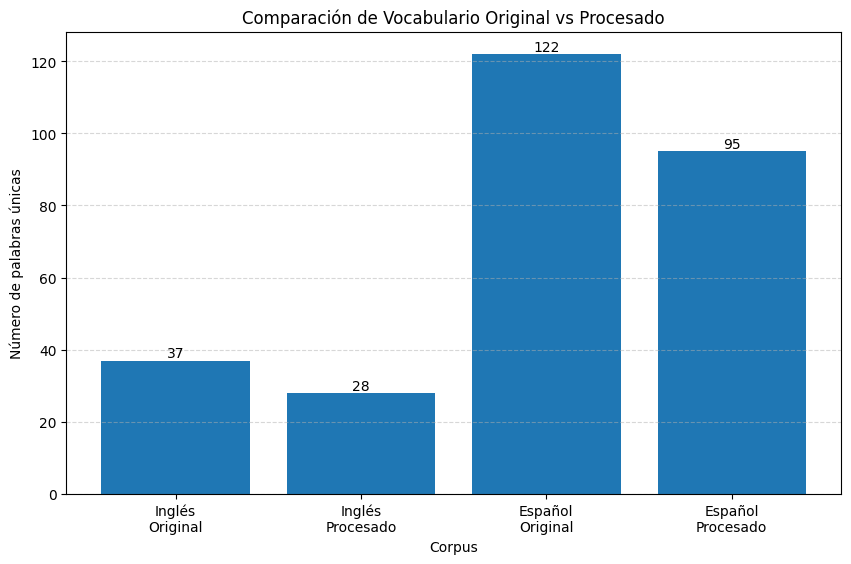

In [21]:

# Calcular vocabulario original y procesado para inglés
vocab_original_en = vocabulario_original(df_corpus_en['texto'])
vocab_procesado_en = vocabulario_procesado(df_corpus_en['tokens'])

# Calcular vocabulario original y procesado para español
vocab_original_es = vocabulario_original(df_noticias_esp['texto'])
vocab_procesado_es = vocabulario_procesado(df_noticias_esp['tokens'])

# Datos para la gráfica
categorias = [
    'Inglés\nOriginal',
    'Inglés\nProcesado',
    'Español\nOriginal',
    'Español\nProcesado'
]

valores = [
    vocab_original_en,
    vocab_procesado_en,
    vocab_original_es,
    vocab_procesado_es
]

# Crear gráfica
plt.figure(figsize=(10,6))
barras = plt.bar(categorias, valores)

# Etiquetas de valor
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        str(altura),
        ha='center',
        va='bottom'
    )

plt.title('Comparación de Vocabulario Original vs Procesado')
plt.ylabel('Número de palabras únicas')
plt.xlabel('Corpus')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()